# Feature Engineering
## Telco Customer Churn Prediction

Raw columns alone miss a lot of the signal. Here we create 10 new features that encode
some of the business patterns found during EDA, then build a preprocessing pipeline
to get the data ready for models.

Sections:
1. Apply feature engineering
2. Feature correlation with target
3. Preprocessing pipeline
4. Handling class imbalance with SMOTE
5. Save processed data

In [16]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.preprocessing import load_data, clean_data, split_data
from src.features import engineer_features, create_preprocessor, get_feature_names

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13, "axes.labelsize": 11})

## 1. Apply Feature Engineering

In [17]:
RAW_PATH = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df_raw   = load_data(RAW_PATH)
df_clean = clean_data(df_raw)

print(f"Before: {df_clean.shape}")
df_eng = engineer_features(df_clean)
print(f"After:  {df_eng.shape}")

new_cols = [c for c in df_eng.columns if c not in df_clean.columns]
print(f"\nNew features created ({len(new_cols)}):")
for i, c in enumerate(new_cols, 1):
    print(f"  {i:2d}. {c}")

df_eng[new_cols].head(10)

No nulls remaining after cleaning.
Before: (7043, 20)
After:  (7043, 30)

New features created (10):
   1. tenure_group
   2. monthly_tenure_ratio
   3. total_services
   4. has_security_bundle
   5. has_support
   6. has_streaming_bundle
   7. is_new_customer
   8. is_high_value
   9. contract_risk
  10. avg_monthly_spend


,tenure_group,monthly_tenure_ratio,total_services,has_security_bundle,has_support,has_streaming_bundle,is_new_customer,is_high_value,contract_risk,avg_monthly_spend
0,0-12,14.925000,2,0,0,0,1,0,2,14.925000
1,25-48,1.627143,4,0,0,0,0,0,1,53.985714
2,0-12,17.950000,4,1,0,0,1,0,2,36.050000
3,25-48,0.919565,4,0,1,0,0,0,1,40.016304
4,0-12,23.566667,2,0,0,0,1,1,2,50.550000
5,0-12,11.072222,6,0,0,1,0,1,2,91.166667
6,13-24,3.873913,5,0,0,0,0,1,2,84.756522
7,0-12,2.704545,2,0,0,0,0,0,2,27.445455
8,25-48,3.613793,7,0,1,1,0,1,2,105.036207
9,49-72,0.891270,4,1,0,0,0,0,1,55.364286


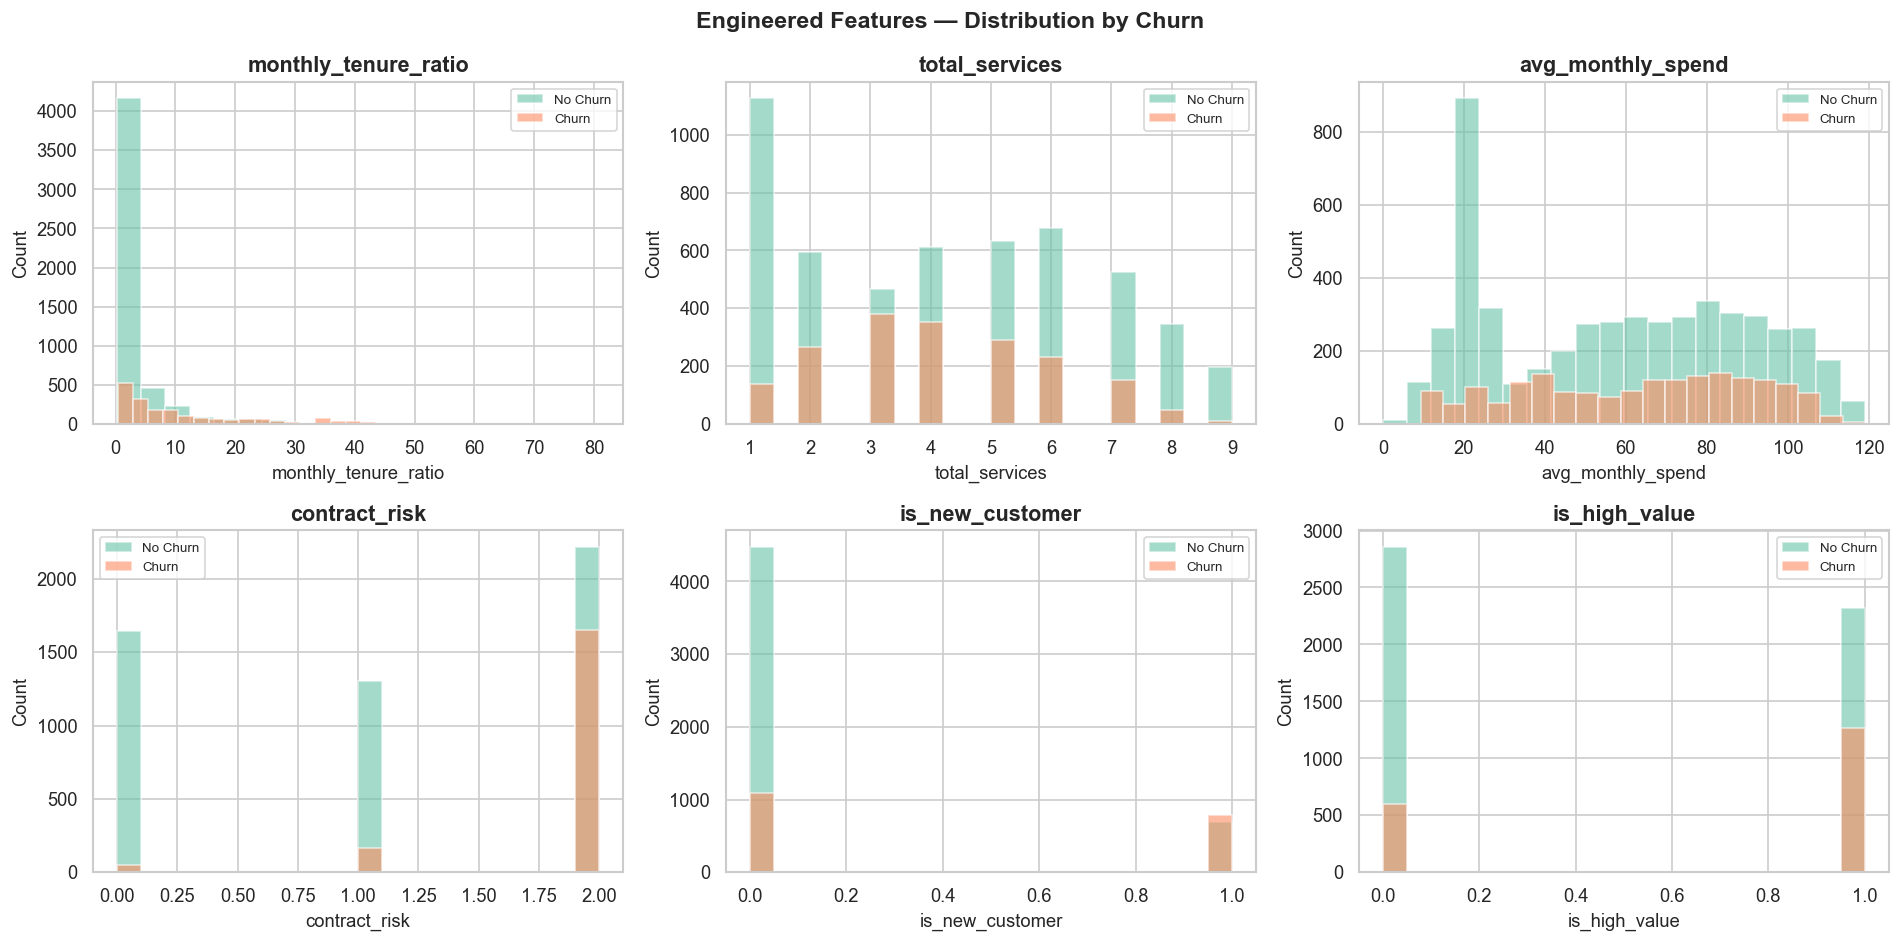

In [18]:
# check distributions of the new numerical features
num_new = ["monthly_tenure_ratio", "total_services", "avg_monthly_spend",
           "contract_risk", "is_new_customer", "is_high_value"]

palette = {0: sns.color_palette("Set2")[0], 1: sns.color_palette("Set2")[1]}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_new):
    for churn_val, color in palette.items():
        subset = df_eng[df_eng["Churn"] == churn_val][col]
        ax.hist(subset, bins=20, alpha=0.6, color=color,
                label=f"{'Churn' if churn_val else 'No Churn'}", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Engineered Features — Distribution by Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/fig_08_engineered_features.png", bbox_inches="tight")
plt.show()

## 2. Feature Correlation with Target

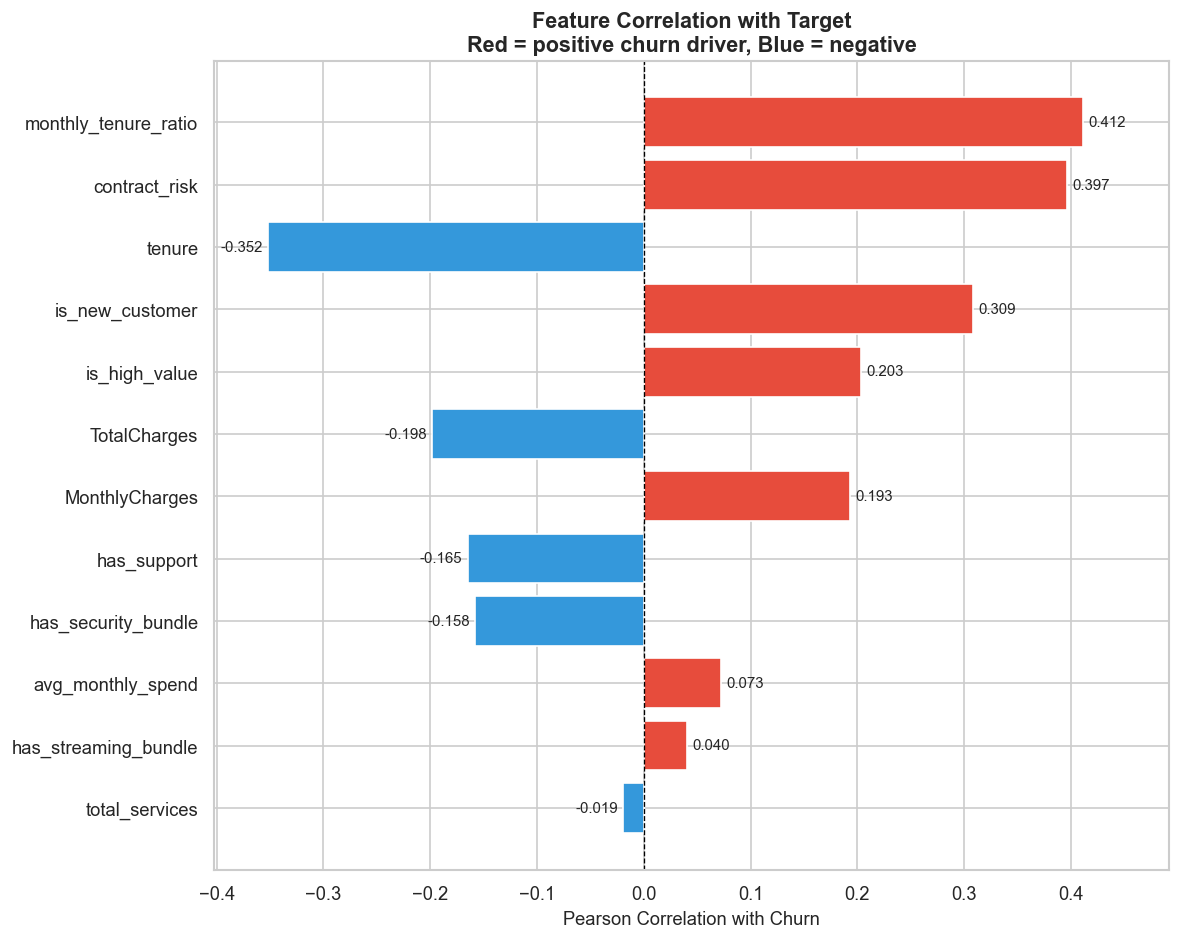

Top 10 features correlated with Churn:
monthly_tenure_ratio    0.411756
contract_risk           0.396713
tenure                 -0.352229
is_new_customer         0.308539
is_high_value           0.203382
TotalCharges           -0.198324
MonthlyCharges          0.193356
has_support            -0.164674
has_security_bundle    -0.157770
avg_monthly_spend       0.072579


In [19]:
num_df = df_eng.select_dtypes(include=[np.number])
corr_with_churn = num_df.corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_with_churn.values]
bars = ax.barh(corr_with_churn.index[::-1], corr_with_churn.values[::-1],
               color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, corr_with_churn.values[::-1]):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha=ha, fontsize=9)
ax.set_xlabel("Pearson Correlation with Churn")
ax.set_title("Feature Correlation with Target\nRed = positive churn driver, Blue = negative",
             fontweight="bold")
ax.set_xlim(corr_with_churn.min() - 0.05, corr_with_churn.max() + 0.08)
plt.tight_layout()
plt.savefig("../reports/fig_09_feature_correlations.png", bbox_inches="tight")
plt.show()

print("Top 10 features correlated with Churn:")
print(corr_with_churn.head(10).to_string())

## 3. Preprocessing Pipeline

One thing I want to be careful about here is data leakage. The scaler and encoder should
only be fit on the training set. If we fit on the full dataset, the model indirectly gets
information about the test set during training, which inflates our metrics.

Using sklearn Pipelines makes this automatic — we call `fit_transform` on train and just
`transform` on test.

In [20]:
X_train, X_test, y_train, y_test = split_data(df_eng)

numerical_cols = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "monthly_tenure_ratio", "total_services", "avg_monthly_spend",
    "contract_risk",
]
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
    "tenure_group",
]

preprocessor = create_preprocessor(numerical_cols, categorical_cols)

# fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"Train feature matrix: {X_train_processed.shape}")
print(f"Test  feature matrix: {X_test_processed.shape}")
print(f"\nOriginal features:  {X_train.shape[1]}")
print(f"After encoding:     {X_train_processed.shape[1]}  (OHE expanded the categoricals)")

Train: 5634 rows  |  churn rate: 26.5%
Test:  1409 rows   |  churn rate: 26.5%
Train feature matrix: (5634, 59)
Test  feature matrix: (1409, 59)

Original features:  29
After encoding:     59  (OHE expanded the categoricals)


## 4. Class Imbalance — SMOTE

Three ways to handle the 73/27 imbalance:

| Approach | How it works |
|----------|-------------|
| `class_weight='balanced'` | Makes the model penalise minority class errors more |
| SMOTE | Generates synthetic minority samples in the training set |
| Threshold tuning | Moves the decision cutoff below 0.5 to catch more churners |

SMOTE is applied to the training set only. Never to the test set.
If we applied SMOTE to test data we'd be evaluating on fake examples, which would
give completely wrong results.

Class distribution before SMOTE:
Churn
No Churn    4139
Churn       1495
Name: count, dtype: int64

Class distribution after SMOTE (training only):
Churn
No Churn    4139
Churn       4139
Name: count, dtype: int64

Training set: 5634 -> 8278 samples


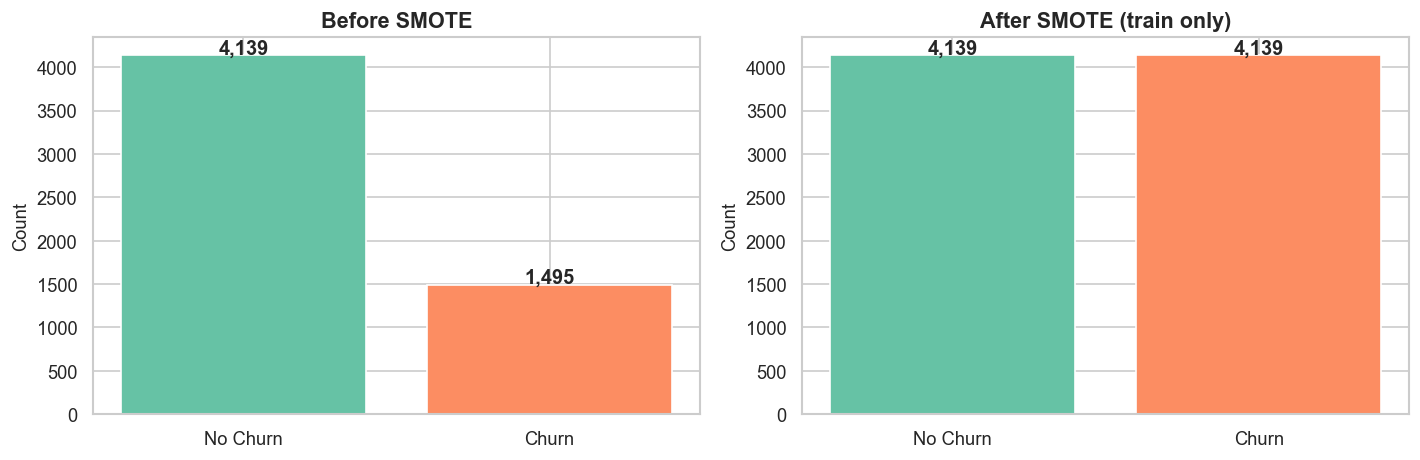

In [21]:
from imblearn.over_sampling import SMOTE

print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts().rename({0: "No Churn", 1: "Churn"}))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("\nClass distribution after SMOTE (training only):")
print(pd.Series(y_train_smote).value_counts().rename({0: "No Churn", 1: "Churn"}))
print(f"\nTraining set: {len(y_train)} -> {len(y_train_smote)} samples")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y_data, title) in zip(axes, [
    (y_train,       "Before SMOTE"),
    (y_train_smote, "After SMOTE (train only)"),
]):
    counts = pd.Series(y_data).value_counts()
    bars = ax.bar(["No Churn", "Churn"], counts.values,
                  color=sns.color_palette("Set2")[:2], edgecolor="white")
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{cnt:,}", ha="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/fig_10_smote_effect.png", bbox_inches="tight")
plt.show()

## 5. Save Processed Data

In [22]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

train_eng = X_train.copy()
train_eng["Churn"] = y_train.values
test_eng  = X_test.copy()
test_eng["Churn"]  = y_test.values

train_eng.to_csv("../data/processed/train.csv", index=False)
test_eng.to_csv( "../data/processed/test.csv",  index=False)

pd.DataFrame(X_train_processed).to_csv("../data/processed/feature_matrix_train.csv", index=False)
pd.DataFrame(X_test_processed).to_csv( "../data/processed/feature_matrix_test.csv",  index=False)

joblib.dump(preprocessor, "../models/preprocessor.joblib")

print("Saved:")
print("  data/processed/train.csv")
print("  data/processed/test.csv")
print("  data/processed/feature_matrix_train.csv")
print("  data/processed/feature_matrix_test.csv")
print("  models/preprocessor.joblib")
print(f"\nFinal feature matrix: {X_train_processed.shape[1]} features")
print(f"Train: {X_train_processed.shape[0]} samples  |  churn rate: {y_train.mean():.1%}")
print(f"Test:  {X_test_processed.shape[0]} samples   |  churn rate: {y_test.mean():.1%}")

Saved:
  data/processed/train.csv
  data/processed/test.csv
  data/processed/feature_matrix_train.csv
  data/processed/feature_matrix_test.csv
  models/preprocessor.joblib

Final feature matrix: 59 features
Train: 5634 samples  |  churn rate: 26.5%
Test:  1409 samples   |  churn rate: 26.5%
